# OpenMeteo

## Forecast API (Single Run)

In [2]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://single-runs-api.open-meteo.com/v1/forecast"
params = {
	"latitude": 52.52,
	"longitude": 13.41,
	"run": "2026-07-20T00:00",
	"hourly": "temperature_2m",
	"models": "ecmwf_ifs",
}
responses = openmeteo.weather_api(url, params = params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process hourly data. The order of variables needs to be the same as requested.
hourly = response.Hourly()
hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()

hourly_data = {
	"date": pd.date_range(
		start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
		end =  pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
		freq = pd.Timedelta(seconds = hourly.Interval()),
		inclusive = "left"
	)
}

hourly_data["temperature_2m"] = hourly_temperature_2m

hourly_dataframe = pd.DataFrame(data = hourly_data)
print("\nHourly data\n", hourly_dataframe)


Coordinates: 52.5483283996582°N 13.407821655273438°E
Elevation: 38.0 m asl
Timezone difference to GMT+0: 0s

Hourly data
                          date  temperature_2m
0   2026-07-20 00:00:00+00:00       14.350000
1   2026-07-20 01:00:00+00:00       13.650000
2   2026-07-20 02:00:00+00:00       13.100000
3   2026-07-20 03:00:00+00:00       13.300000
4   2026-07-20 04:00:00+00:00       13.400000
..                        ...             ...
163 2026-07-26 19:00:00+00:00       22.334375
164 2026-07-26 20:00:00+00:00       21.411112
165 2026-07-26 21:00:00+00:00       20.490625
166 2026-07-26 22:00:00+00:00       19.633335
167 2026-07-26 23:00:00+00:00       18.899654

[168 rows x 2 columns]


## Previous Runs API

In [3]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://previous-runs-api.open-meteo.com/v1/forecast"
params = {
	"latitude": 52.52,
	"longitude": 13.41,
	"hourly": ["temperature_2m", "temperature_2m_previous_day1", "temperature_2m_previous_day2", "temperature_2m_previous_day3", "temperature_2m_previous_day4", "temperature_2m_previous_day5"],
	"past_days": 7,
	"forecast_days": 1,
}
responses = openmeteo.weather_api(url, params = params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process hourly data. The order of variables needs to be the same as requested.
hourly = response.Hourly()
hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()
hourly_temperature_2m_previous_day1 = hourly.Variables(1).ValuesAsNumpy()
hourly_temperature_2m_previous_day2 = hourly.Variables(2).ValuesAsNumpy()
hourly_temperature_2m_previous_day3 = hourly.Variables(3).ValuesAsNumpy()
hourly_temperature_2m_previous_day4 = hourly.Variables(4).ValuesAsNumpy()
hourly_temperature_2m_previous_day5 = hourly.Variables(5).ValuesAsNumpy()

hourly_data = {
	"date": pd.date_range(
		start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
		end =  pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
		freq = pd.Timedelta(seconds = hourly.Interval()),
		inclusive = "left"
	)
}

hourly_data["temperature_2m"] = hourly_temperature_2m
hourly_data["temperature_2m_previous_day1"] = hourly_temperature_2m_previous_day1
hourly_data["temperature_2m_previous_day2"] = hourly_temperature_2m_previous_day2
hourly_data["temperature_2m_previous_day3"] = hourly_temperature_2m_previous_day3
hourly_data["temperature_2m_previous_day4"] = hourly_temperature_2m_previous_day4
hourly_data["temperature_2m_previous_day5"] = hourly_temperature_2m_previous_day5

hourly_dataframe = pd.DataFrame(data = hourly_data)
print("\nHourly data\n", hourly_dataframe)


Coordinates: 52.52000045776367°N 13.419998168945312°E
Elevation: 38.0 m asl
Timezone difference to GMT+0: 0s

Hourly data
                          date  temperature_2m  temperature_2m_previous_day1  \
0   2026-07-14 00:00:00+00:00       18.895500                     17.845499   
1   2026-07-14 01:00:00+00:00       18.195499                     17.245501   
2   2026-07-14 02:00:00+00:00       17.645500                     16.945499   
3   2026-07-14 03:00:00+00:00       17.195499                     16.895500   
4   2026-07-14 04:00:00+00:00       17.045500                     16.845499   
..                        ...             ...                           ...   
187 2026-07-21 19:00:00+00:00       21.245501                     20.695499   
188 2026-07-21 20:00:00+00:00       20.045500                     19.795500   
189 2026-07-21 21:00:00+00:00       19.295500                     18.945499   
190 2026-07-21 22:00:00+00:00       18.795500                     17.945499   
191 2026

## Historical Weather API

In [4]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
	"latitude": 52.52,
	"longitude": 13.41,
	"start_date": "2026-07-05",
	"end_date": "2026-07-19",
	"hourly": "temperature_2m",
}
responses = openmeteo.weather_api(url, params = params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process hourly data. The order of variables needs to be the same as requested.
hourly = response.Hourly()
hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()

hourly_data = {
	"date": pd.date_range(
		start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
		end =  pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
		freq = pd.Timedelta(seconds = hourly.Interval()),
		inclusive = "left"
	)
}

hourly_data["temperature_2m"] = hourly_temperature_2m

hourly_dataframe = pd.DataFrame(data = hourly_data)
print("\nHourly data\n", hourly_dataframe)


Coordinates: 52.5483283996582°N 13.407821655273438°E
Elevation: 38.0 m asl
Timezone difference to GMT+0: 0s

Hourly data
                          date  temperature_2m
0   2026-07-05 00:00:00+00:00           15.45
1   2026-07-05 01:00:00+00:00           15.30
2   2026-07-05 02:00:00+00:00           14.95
3   2026-07-05 03:00:00+00:00           15.00
4   2026-07-05 04:00:00+00:00           15.40
..                        ...             ...
355 2026-07-19 19:00:00+00:00           14.20
356 2026-07-19 20:00:00+00:00           13.90
357 2026-07-19 21:00:00+00:00           14.15
358 2026-07-19 22:00:00+00:00           14.10
359 2026-07-19 23:00:00+00:00           13.80

[360 rows x 2 columns]


## Merge Actual and Forecasts

In [5]:
def dataframe_from_response(response):
    # Process hourly data. The order of variables needs to be the same as requested.
    hourly = response.Hourly()
    
    hourly_data = {
    	"date": pd.date_range(
    		start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
    		end =  pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
    		freq = pd.Timedelta(seconds = hourly.Interval()),
    		inclusive = "left"
    	)
    }
    
    hourly_data["var_0"] = hourly.Variables(0).ValuesAsNumpy()
    
    hourly_dataframe = pd.DataFrame(data = hourly_data)
    return hourly_dataframe

In [6]:
def error_dataframe_from_responses(actual_response, forecast_response):
    df = dataframe_from_response(actual_response)
    df2 = dataframe_from_response(forecast_response)
    
    df = df.rename(columns={"var_0": "actual"})
    df2 = df2.rename(columns={"var_0": "forecast"})
    df['forecast'] = df2['forecast']
    df['error'] = df['actual'] - df['forecast']
    return df



def error_dataframe_for_params(params):
    url_archive = "https://archive-api.open-meteo.com/v1/archive"
    actual_responses = openmeteo.weather_api(url_archive, params = params)
    
    url_previous_runs = "https://previous-runs-api.open-meteo.com/v1/forecast"
    params["hourly"] = [params["hourly"] + "_previous_day1"]
    forecast_responses = openmeteo.weather_api(url_previous_runs, params = params)
    df = None
    for i,_ in enumerate(actual_responses):
        actual_response = actual_responses[i]    
        forecast_response = forecast_responses[i]
        current_df = error_dataframe_from_responses(actual_response, forecast_response)
        if df is None:
            df = current_df[["date"]]
        df[f"error_{i}"] = current_df["error"]
        df[f"lat_{i}"] = actual_response.Latitude()
        df[f"lon_{i}"] = actual_response.Longitude()
     
        
    return df 







## Correlation of errors

In [7]:
import numpy as np


lat_grid = []
lon_grid = []
lats = np.arange(40.0,55.0,1.0)
lons = np.arange(5.0,15.0,1.0)
for lat in lats:
    for lon in lons:
        lat_grid.append(lat)
        lon_grid.append(lon)

params = {
    	"latitude": lat_grid,
    	"longitude": lon_grid,
    	"start_date": "2026-01-05",
    	"end_date": "2026-07-19",
    	"hourly": "temperature_2m",
    }

df = error_dataframe_for_params(params)
error_cols = [f"error_{i}" for i,_ in enumerate(lat_grid)]
error_df = df[error_cols]


/tmp/ipykernel_1433302/3894198977.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"lat_{i}"] = actual_response.Latitude()
/tmp/ipykernel_1433302/3894198977.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"lon_{i}"] = actual_response.Longitude()
/tmp/ipykernel_1433302/3894198977.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-f

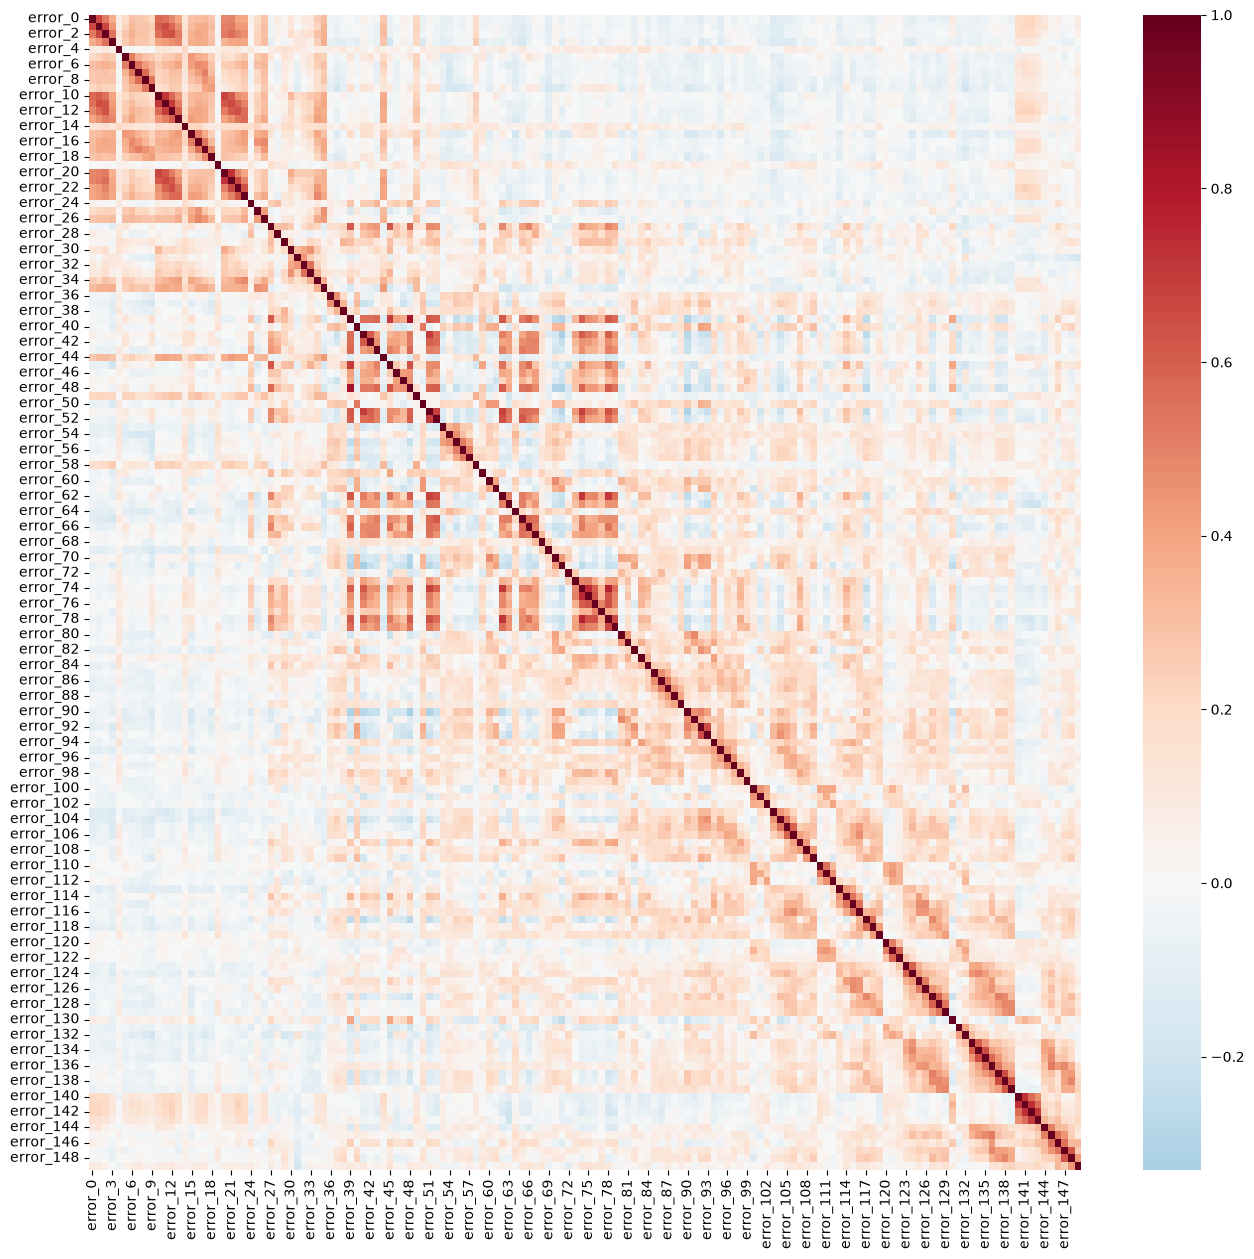

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

error_corr = error_df.corr() 
plt.figure(figsize=(16,15))
sns.heatmap(error_corr, cmap="RdBu_r", center =0);

Some interesting patterns arise, when looking at the heatmap of the correlation matrix of the temperature prediction errors. While, of course the grid projected into linear space has its own structure ("line breaks", where lat changes one step and lon jumps from max to min), we can see regions in the middle, where there are much stronger correlations than in other comparable regions (42\~76 vs 90\~120). Also, we can see the correlation rise between the first locations and the last ones (around 40°N) and the last ones (around 55°N).  
As we will see when comparing other variables, every variable has its own pattern.

## Correlation vs distance
### Correlation of temperature vs distance

In [43]:
from  geopy import distance


def distances_to_point(my_index):
    distances = []
    reference_point = (lat_grid[my_index], lon_grid[my_index])
    for i,_ in enumerate(lon_grid):
        comparison_point = (lat_grid[i], lon_grid[i])
        distances.append(distance.distance(reference_point, comparison_point).km)    
    return distances

def plot_errors_vs_distance(error_corr, my_index, new_figure=True):
    if new_figure:
        plt.figure(figsize=(16,15))
    #sns.scatterplot(x=lon_grid,y=lat_grid, size=error_corr[f"error_{my_index}"]);
    distances = distances_to_point(my_index)
    plt.scatter(distances, error_corr[f"error_{my_index}"])

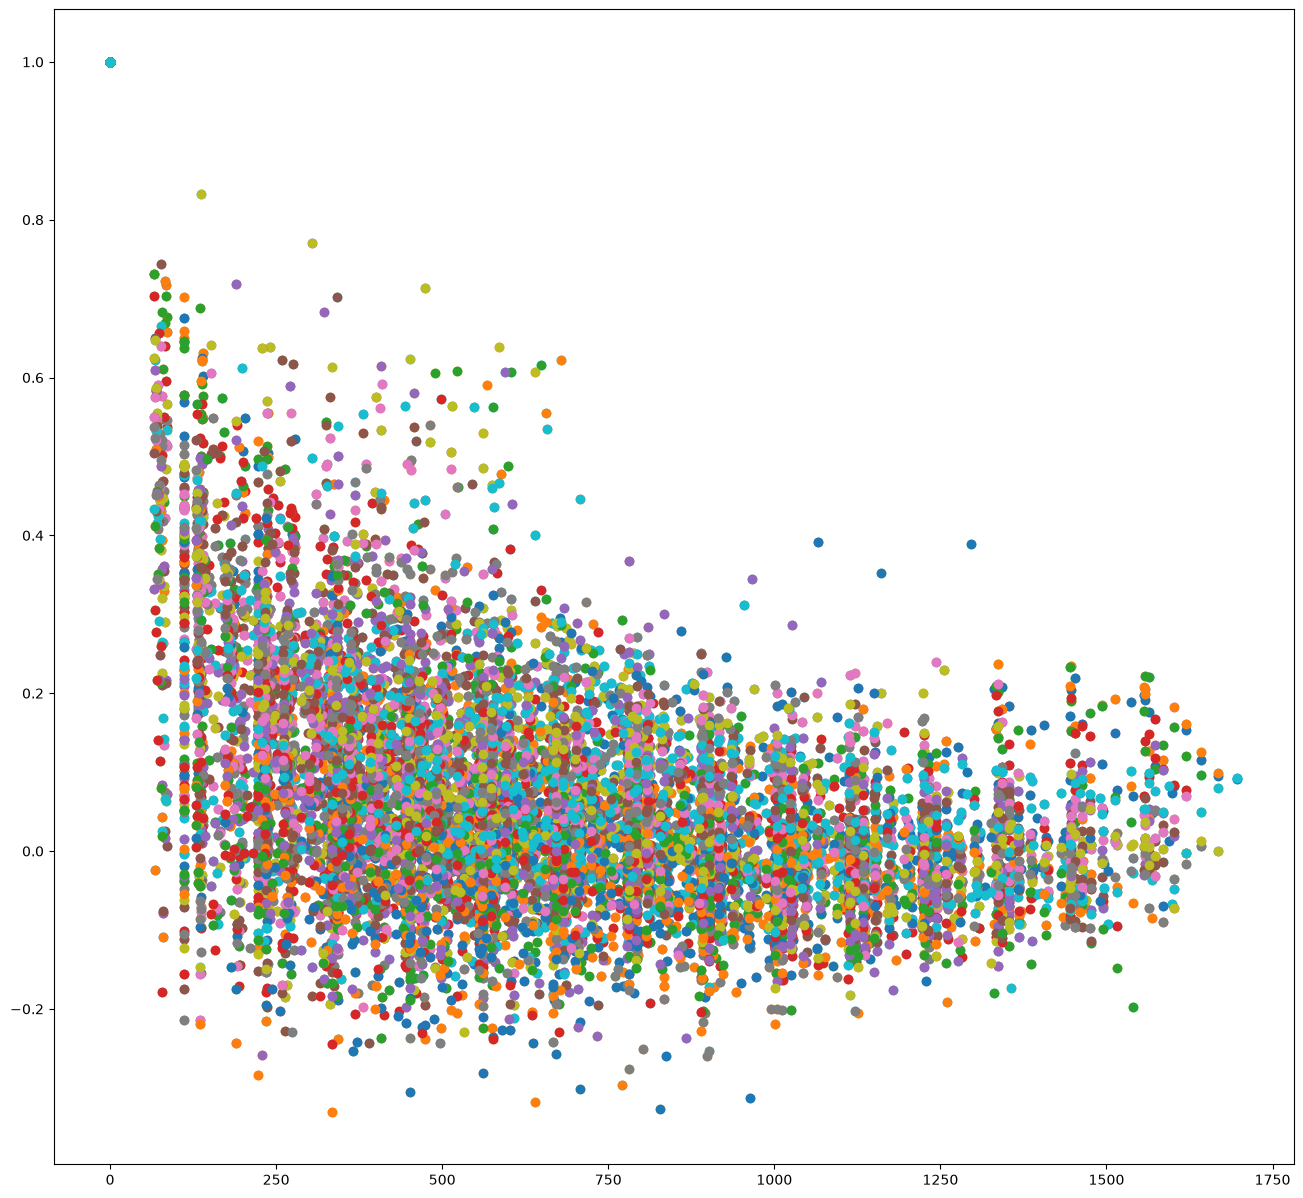

In [44]:


for i,_ in enumerate(lat_grid):
    plot_errors_vs_distance(error_corr, i, i==0)


### Correlation of cloudiness vs distance

In [20]:
params = {
    	"latitude": lat_grid,
    	"longitude": lon_grid,
    	"start_date": "2026-01-05",
    	"end_date": "2026-07-19",
    	"hourly": "cloud_cover",
    }

cloud_df = error_dataframe_for_params(params)

cloud_error_df = cloud_df[error_cols]


In [24]:
cloud_error_corr = cloud_error_df.corr()

Task was destroyed but it is pending!
task: <Task pending name='Task-256' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/soeren/PycharmProjects/weather_forecast_analysis/.venv/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-257' coro=<Kernel.shell_main() running at /home/soeren/PycharmProjects/weather_forecast_analysis/.venv/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /home/soeren/PycharmProjects/weather_forecast_analysis/.venv/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:563]>
/home/soeren/PycharmProjects/weather_forecast_analysis/.venv/lib/python3.12/site-packages/matplotlib/_api/__init__.py:214: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  for key, val in kwargs.items():
Task was destroyed but it is pending!
task: <Task pending name='Task-257' coro=<Kernel.shell_main() running at /home/soeren/Pycha

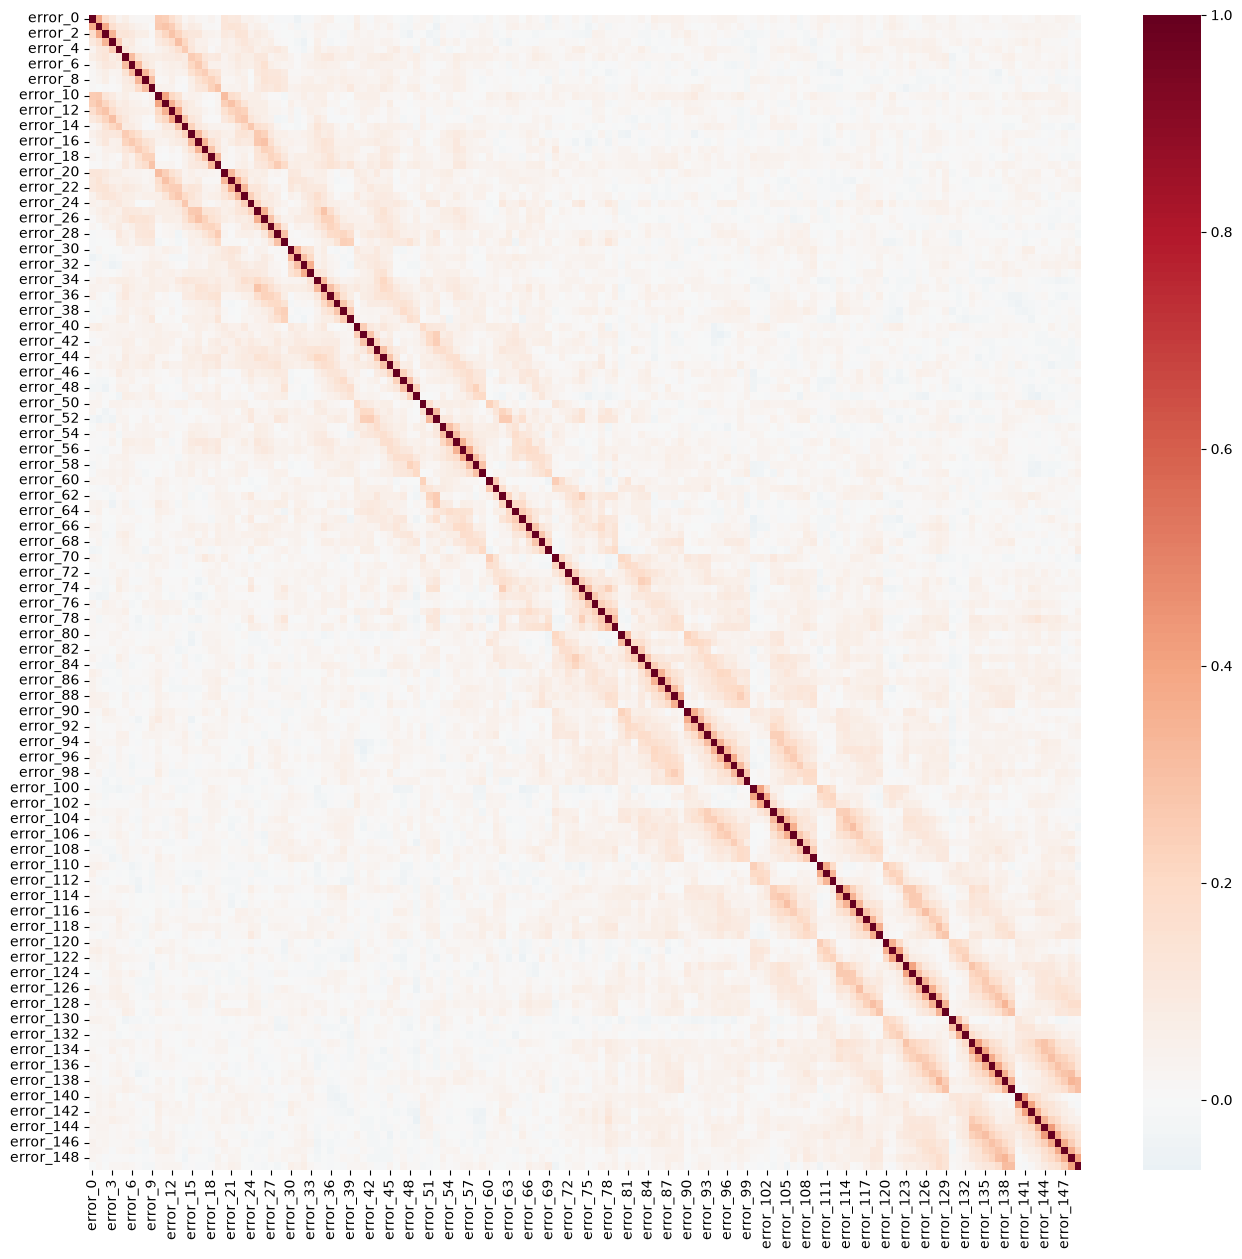

In [45]:
plt.figure(figsize=(16,15))
sns.heatmap(cloud_error_corr, cmap="RdBu_r", center =0);

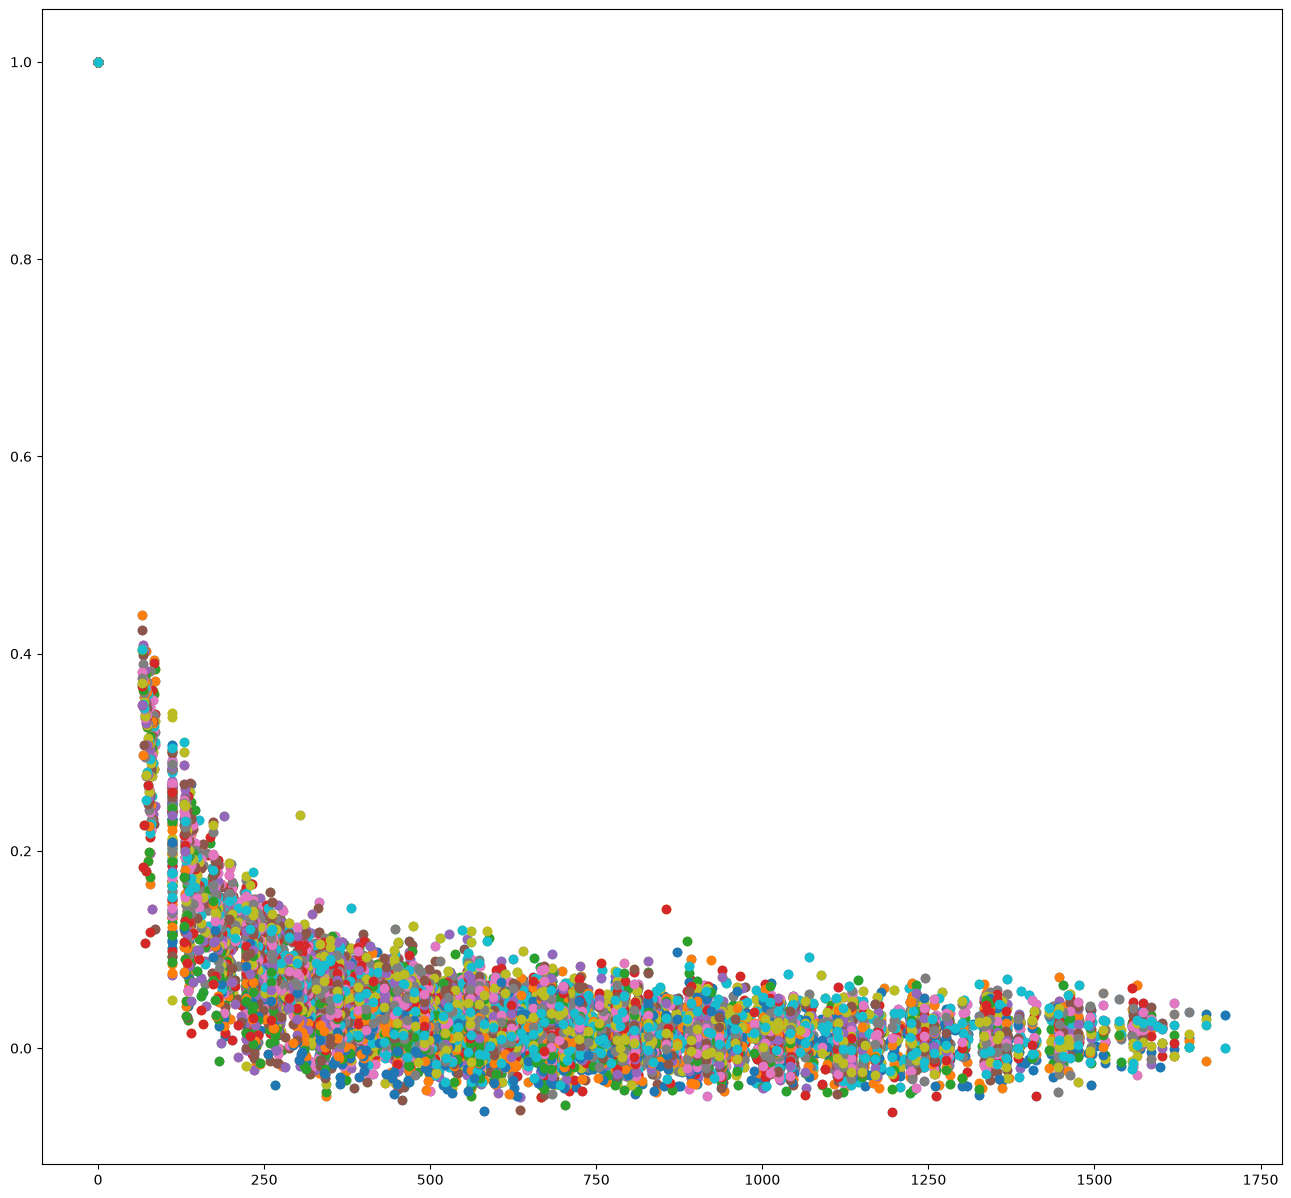

In [42]:
for i,_ in enumerate(lat_grid):
    plot_errors_vs_distance(cloud_error_corr, i, i==0)

Clod coverage seems to have a quite stable correlation distribution: For most places in the dataset, other places' errors for the cloud_coverage forecast are correlated with a coefficient below ~0.2, once the distance goes beyond 200km. Other variables show a less stable behaviour.

### Correlation of Wind Speed vs Distance

In [31]:
params = {
    	"latitude": lat_grid,
    	"longitude": lon_grid,
    	"start_date": "2026-01-05",
    	"end_date": "2026-07-19",
    	"hourly": "wind_speed_10m",
    }

wind_df = error_dataframe_for_params(params)

wind_error_df = wind_df[error_cols]

/tmp/ipykernel_1433302/3894198977.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"lat_{i}"] = actual_response.Latitude()
/tmp/ipykernel_1433302/3894198977.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"lon_{i}"] = actual_response.Longitude()
/tmp/ipykernel_1433302/3894198977.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-f

In [32]:
wind_error_corr = wind_error_df.corr()

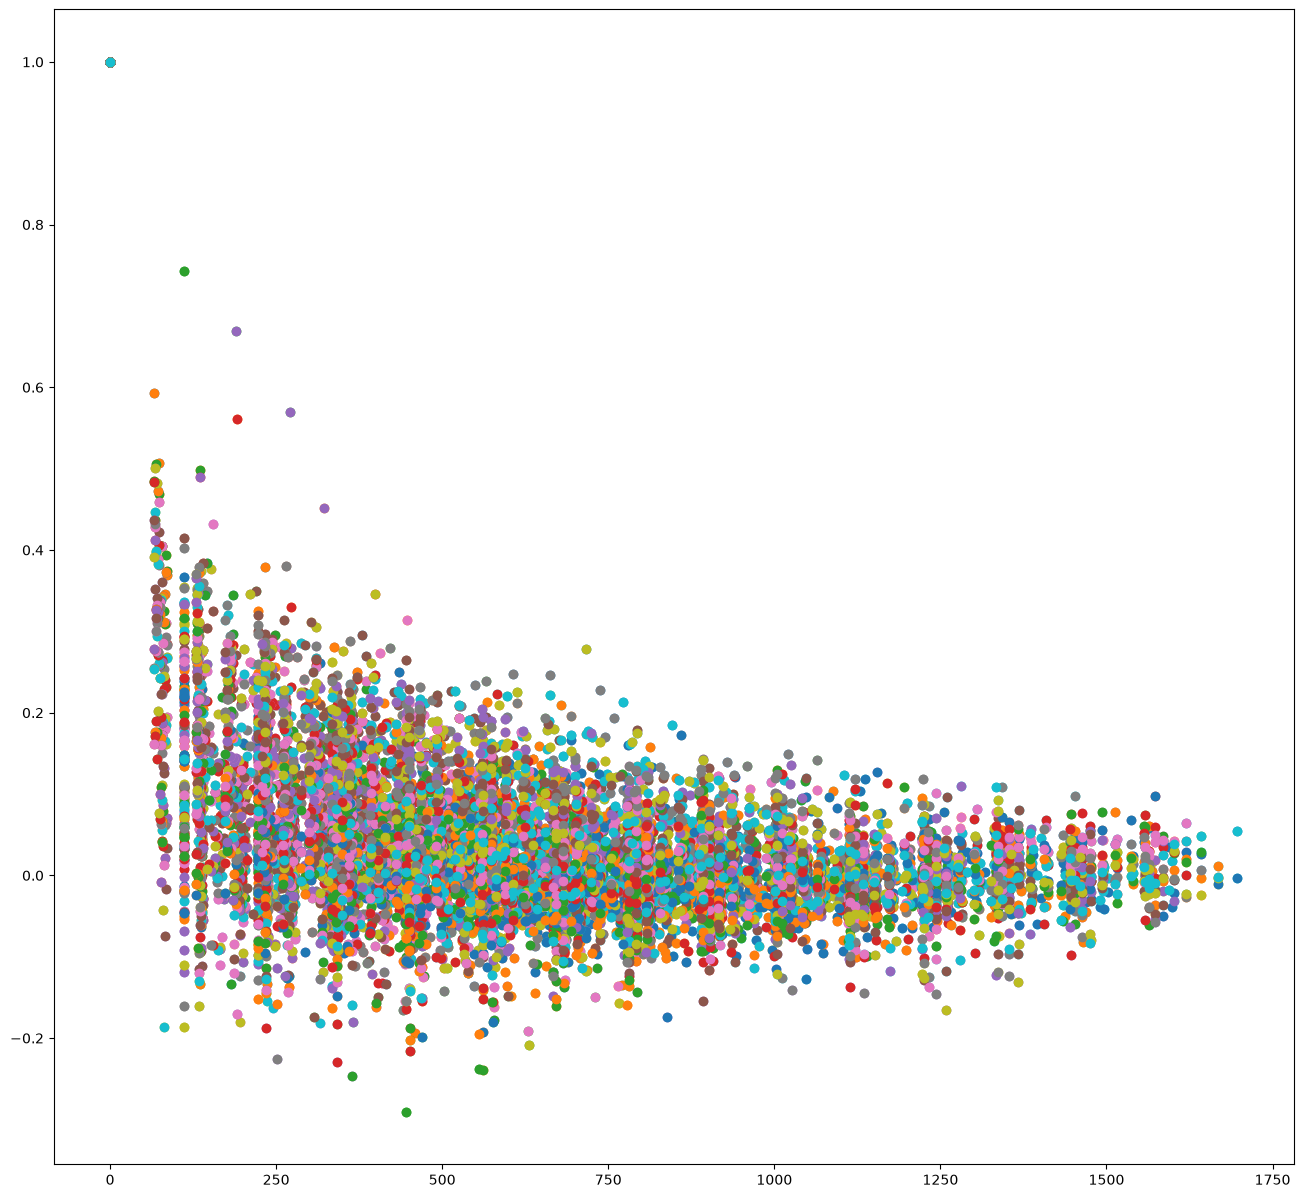

In [41]:
for i,_ in enumerate(lat_grid):
    plot_errors_vs_distance(wind_error_corr, i, i==0)
    

The errors of wind_speed are much more correlated below 500km. You need to go roughly twice as far to reduce the correlation by the same amount than for cloud_coverage.
But there are also very negative correlations. Since we are comparing more than have a year of forecast errors, that might be worth examining: With that many data, it does not seem like a coincidence. Maybe, under certain conditions, these negative correlations can be used for errors to cancel out. Even if they are artifacts of the model, they could be used, when the correlations stay stable. 

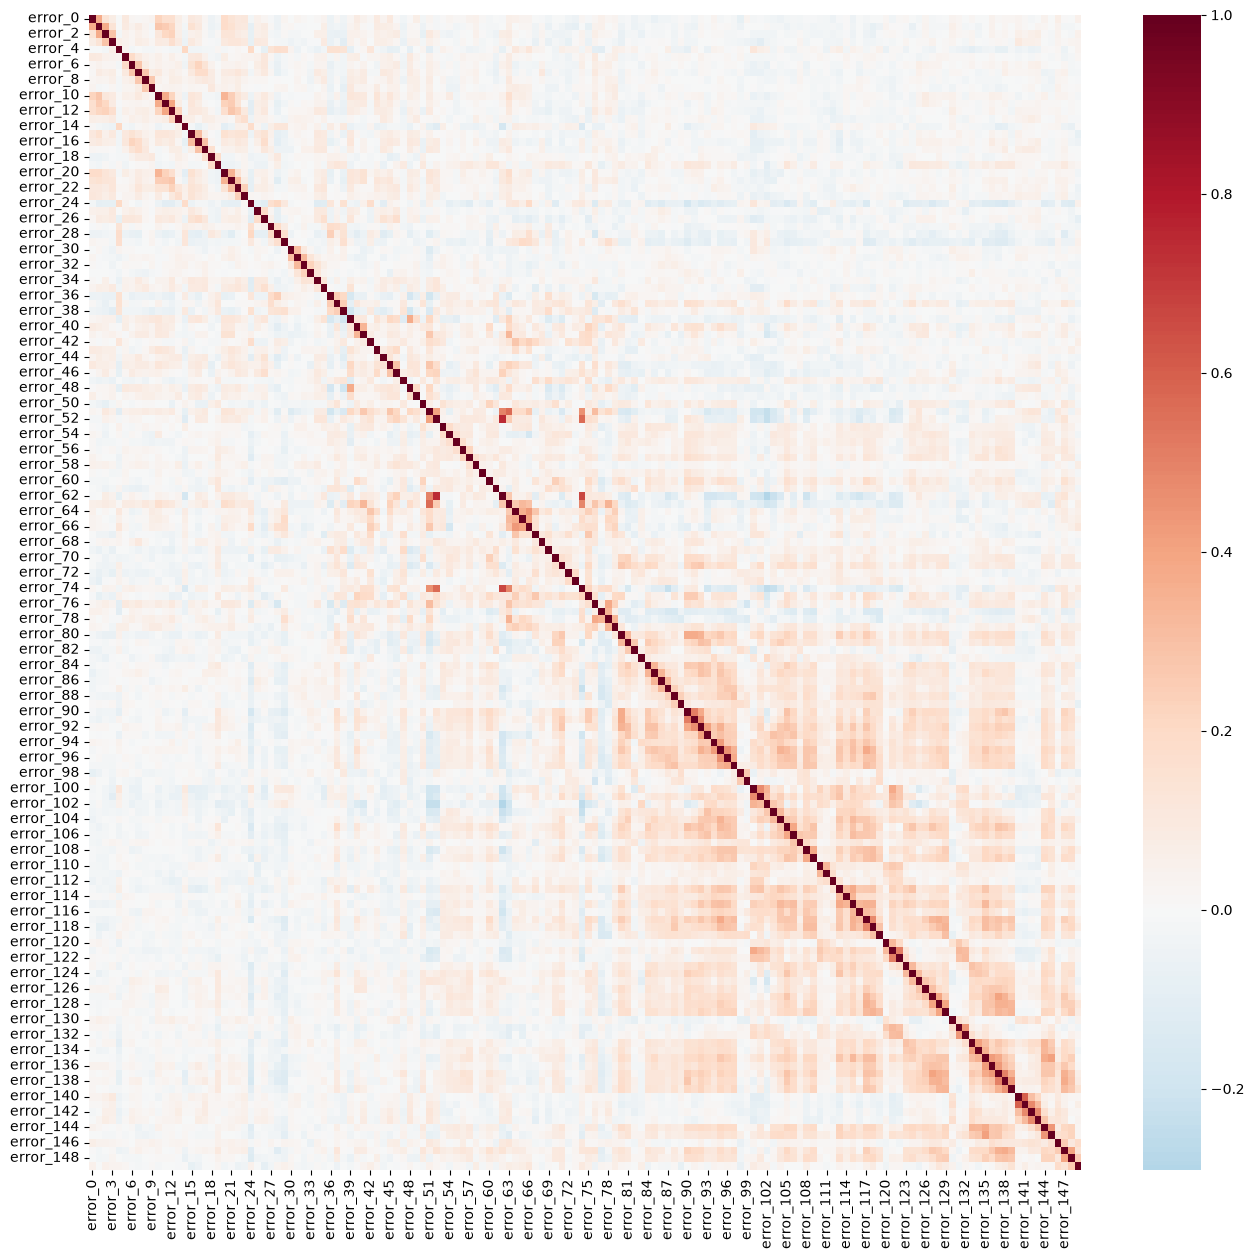

In [46]:
plt.figure(figsize=(16,15))
sns.heatmap(wind_error_corr, cmap="RdBu_r", center =0);

Examining the pattern of wind_speed prediction error correlations, we observe the following:  
There are dedicated spots of strong correlation in the middle, while the higher indices generally have a stronger correlation. That might be a hint that geography plays a big role here (and in the temperature pattern examined above): In this example, higher indices mean further up north, which in turn means at these longitudinal values "northern Germany, Denmark and North/Baltic Sea". Generally areas with little to no elevation and where athmosperical pressures are somewhat undisturbed from high mountains.
I should find a way to properly visualize these correlations on a geographical map so that we can further examine the relation between error correlation and geography.  
Another thing to investigate would be the stability of the patterns over the year and over the years and in other models to see if they are really meaningful or just ephimeral artifacts of one model.